# Yellow Dust Dataset - Preprocessing and EDA for V5 additional features

Contains China and Japan data. Yellow dust dataset from the Copernicus Atmosphere Monitoring Service.

## Processing first, renaming the columns to match other datasets

In [16]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h3
from datetime import timezone
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import libpysal
from esda.moran import Moran
from scipy.spatial import cKDTree
import folium
from folium.plugins import MarkerCluster
import gc
from prophet import Prophet

In [4]:
def process_data_in_chunks(csv_path, chunksize=100_000):
    """Processes a large CSV file in chunks to avoid memory issues."""

    for chunk in pd.read_csv(csv_path, chunksize=chunksize):
        # 1. Data Cleaning/Transformation (Example)
        chunk['timestamp'] = pd.to_datetime(chunk['valid_time'], utc=True, errors='coerce')
        chunk.drop(columns=['valid_time'], inplace=True)
        chunk.rename(columns={'latitude': 'lat', 'longitude': 'lon', 'pm2p5': 'pm25', 'pm10': 'pm10'}, inplace=True)

        # 2. Data Analysis/Aggregation (Example)
        # Perform your analysis on the chunk here
        print(f"Chunk processed. Shape: {chunk.shape}")
        print(chunk.head()) #Print the head of the chunk

        # 3. Explicitly Delete the Chunk
        del chunk

        # 4. Force Garbage Collection
        gc.collect()

# Call the function
csv_path = "/home/julia/smoglens/data/data_sfc.csv"
process_data_in_chunks(csv_path)

Chunk processed. Shape: (100000, 12)
    lat    lon       u10       v10        t2m  bcaod550  duaod550       lsm  \
0  49.5  70.00  2.817483  3.943344  266.94460  0.000206  0.000011  0.989188   
1  49.5  70.75  2.887795  5.084457  266.28055  0.000199  0.000010  0.995354   
2  49.5  71.50  2.983499  5.849106  265.50906  0.000203  0.000010  0.994766   
3  49.5  72.25  3.118264  6.141586  264.61650  0.000223  0.000009  0.992191   
4  49.5  73.00  3.338479  5.872055  263.29813  0.000263  0.000009  0.990747   

           pm25          pm10         sp                 timestamp  
0  7.730705e-12  1.159606e-11  97576.125 2023-01-01 00:00:00+00:00  
1  7.275958e-12  1.068656e-11  97371.125 2023-01-01 00:00:00+00:00  
2  3.296918e-12  4.774847e-12  97140.125 2023-01-01 00:00:00+00:00  
3  3.240075e-11  4.604317e-11  96743.125 2023-01-01 00:00:00+00:00  
4  8.753886e-11  1.242597e-10  95869.125 2023-01-01 00:00:00+00:00  
Chunk processed. Shape: (100000, 12)
          lat     lon        u10     

### Meaning of column abbreviations

- **Shape:** 6,879,672 rows × 12 columns.
- **Columns:**  
  - `timestamp` (datetime): Measurement time (UTC).
  - `lat`, `lon`: Geographic coordinates.
  - `u10`, `v10`: Wind components at 10m (m/s).
  - `t2m`: Temperature at 2m (K).
  - `bcaod550`: Black carbon aerosol optical depth.
  - `duaod550`: Dust aerosol optical depth.
  - `lsm`: Land-sea mask (1=land, 0=sea).
  - `pm25`, `pm10`: Particulate matter concentrations (µg/m³).
  - `sp`: Surface pressure (Pa).

## Dask
For more complex EDA or analysis, Dask is highly recommended. It allows you to perform operations on datasets larger than memory by breaking them into smaller chunks and processing them in parallel.

In [5]:
import dask.dataframe as dd

# Define data types for columns to optimize memory usage
dtype = {
    'latitude': 'float32',
    'longitude': 'float32',
    'pm2p5': 'float32',
    'pm10': 'float32',
    'u10': 'float32',
    'v10': 'float32',
    't2m': 'float32',
    'bcaod550': 'float32',
    'duaod550': 'float32',
    'lsm': 'float32',
    'sp': 'float32'
}

csv_path = "/home/julia/smoglens/data/data_sfc.csv"
ddf = dd.read_csv(csv_path, parse_dates=['valid_time'], dtype=dtype).compute()

ddf['timestamp'] = pd.to_datetime(ddf['valid_time'], utc=True)
ddf.drop(columns=['valid_time'], inplace=True)
ddf.rename(columns={'latitude': 'lat', 'longitude': 'lon', 'pm2p5': 'pm25', 'pm10': 'pm10'}, inplace=True)

print(ddf.head())
print(ddf.info())

    lat    lon       u10       v10         t2m  bcaod550  duaod550       lsm  \
0  49.5  70.00  2.817483  3.943344  266.944611  0.000206  0.000011  0.989188   
1  49.5  70.75  2.887795  5.084457  266.280548  0.000199  0.000010  0.995354   
2  49.5  71.50  2.983499  5.849106  265.509064  0.000203  0.000010  0.994766   
3  49.5  72.25  3.118264  6.141586  264.616486  0.000223  0.000009  0.992191   
4  49.5  73.00  3.338479  5.872055  263.298126  0.000263  0.000009  0.990747   

           pm25          pm10         sp                 timestamp  
0  7.730705e-12  1.159606e-11  97576.125 2023-01-01 00:00:00+00:00  
1  7.275958e-12  1.068656e-11  97371.125 2023-01-01 00:00:00+00:00  
2  3.296918e-12  4.774847e-12  97140.125 2023-01-01 00:00:00+00:00  
3  3.240075e-11  4.604317e-11  96743.125 2023-01-01 00:00:00+00:00  
4  8.753887e-11  1.242597e-10  95869.125 2023-01-01 00:00:00+00:00  
<class 'pandas.core.frame.DataFrame'>
Index: 29409592 entries, 0 to 487585
Data columns (total 12 columns

## EDA --- Step 1: Data Overview ---

In [6]:
print("Memory usage (MB):", ddf.memory_usage(deep=True).sum() / 1e6)
print("Time range:", ddf['timestamp'].min(), "to", ddf['timestamp'].max())
print("Unique locations (lat, lon):", ddf[['lat', 'lon']].drop_duplicates().shape[0])

print("\nMissing values per column:\n", ddf.isnull().mean().round(3) * 100)
print("\nFirst 5 rows:\n", ddf.head())

Memory usage (MB): 1764.57552


Time range: 2023-01-01 00:00:00+00:00 to 2024-12-31 21:00:00+00:00
Unique locations (lat, lon): 5029

Missing values per column:
 lat          0.0
lon          0.0
u10          0.0
v10          0.0
t2m          0.0
bcaod550     0.0
duaod550     0.0
lsm          0.0
pm25         0.0
pm10         0.0
sp           0.0
timestamp    0.0
dtype: float64

First 5 rows:
     lat    lon       u10       v10         t2m  bcaod550  duaod550       lsm  \
0  49.5  70.00  2.817483  3.943344  266.944611  0.000206  0.000011  0.989188   
1  49.5  70.75  2.887795  5.084457  266.280548  0.000199  0.000010  0.995354   
2  49.5  71.50  2.983499  5.849106  265.509064  0.000203  0.000010  0.994766   
3  49.5  72.25  3.118264  6.141586  264.616486  0.000223  0.000009  0.992191   
4  49.5  73.00  3.338479  5.872055  263.298126  0.000263  0.000009  0.990747   

           pm25          pm10         sp                 timestamp  
0  7.730705e-12  1.159606e-11  97576.125 2023-01-01 00:00:00+00:00  
1  7.275958e-12 

## --- Step 2: Data Quality Assessment ---

In [7]:
# Outlier detection
import numpy as np
for col in ['pm25', 'pm10', 't2m', 'u10', 'v10', 'sp']:
    q1 = ddf[col].quantile(0.25)
    q3 = ddf[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((ddf[col] < (q1 - 1.5 * iqr)) | (ddf[col] > (q3 + 1.5 * iqr))).sum()
    print(f"{col}: {outliers} outliers ({outliers/len(ddf)*100:.2f}%)")

# Value range checks
print("Negative PM2.5:", (ddf['pm25'] < 0).sum())
print("Negative PM10:", (ddf['pm10'] < 0).sum())
print("Temperature out of range (<200K or >330K):", ((ddf['t2m'] < 200) | (ddf['t2m'] > 330)).sum())
print("LSM out of [0,1]:", ((ddf['lsm'] < 0) | (ddf['lsm'] > 1)).sum())

# Duplicates
dupes = ddf.duplicated(subset=['timestamp', 'lat', 'lon']).sum()
print("Duplicate records (timestamp, lat, lon):", dupes)


pm25: 2942349 outliers (10.00%)
pm10: 2986076 outliers (10.15%)
t2m: 233864 outliers (0.80%)
u10: 2270770 outliers (7.72%)
v10: 2154466 outliers (7.33%)
sp: 2728144 outliers (9.28%)
Negative PM2.5: 0
Negative PM10: 0
Temperature out of range (<200K or >330K): 0
LSM out of [0,1]: 0
Duplicate records (timestamp, lat, lon): 0


### A 10% outlier rate is generally considered moderately high and could have a noticeable impact on time series modeling, especially with a sensitive model like Prophet.

### Data Consistency
- **Value Ranges:**  
  - PM2.5/PM10 should be ≥ 0.
  - Temperature (t2m) should be within realistic atmospheric bounds.
  - lsm between 0 and 1.

The relatively high percentage of outliers in PM2.5 and PM10 suggests substantial variability or the presence of extreme pollution events in the dataset. Wind and pressure variables also show notable outlier rates, which may reflect meteorological extremes or data quality issues. Temperature outliers are much less frequent, indicating more stable measurements.

No negative or physically impossible values were found for PM2.5, PM10, temperature, or land-sea mask, indicating good basic data quality. There are also no duplicate records for the combination of timestamp, latitude, and longitude, confirming uniqueness of observations.

## --- Step 3: Temporal Patterns ---


Hourly patterns (24-hour cycle):


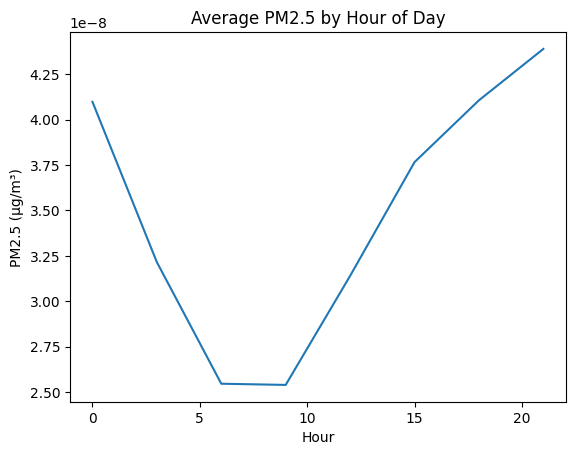


Day of week effects (weekday vs weekend):


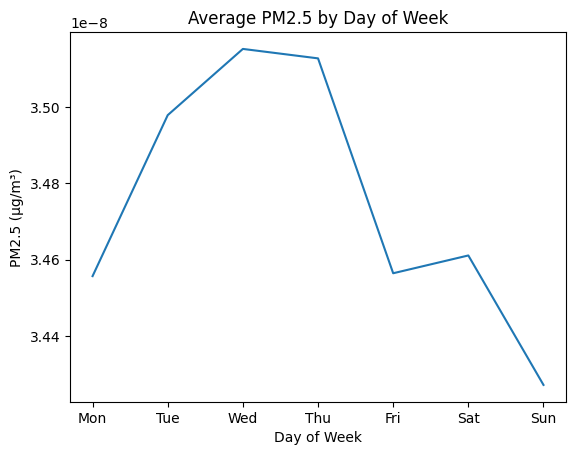


Monthly trends and seasonal patterns:


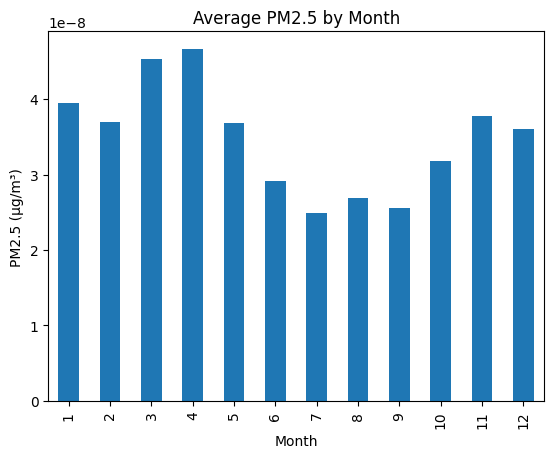


Year-over-year comparison (daily means):


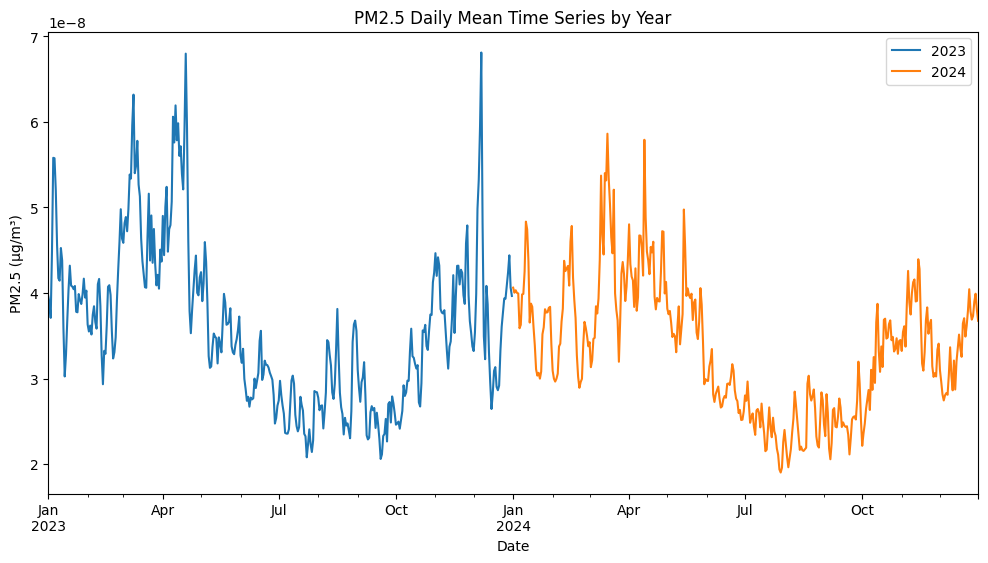


Autocorrelation Analysis:

ACF and PACF plots:


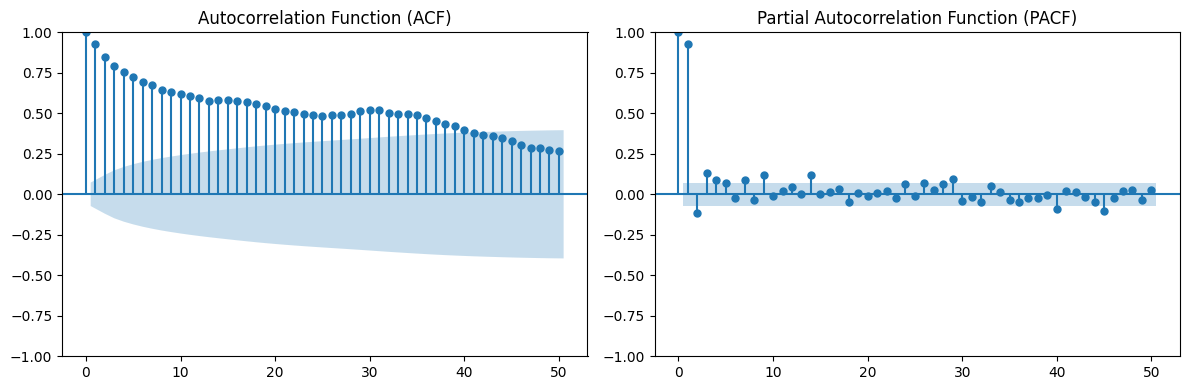


Lag correlation analysis: 1h, 3h, 6h, 12h, 24h, 1 week:
Correlation with lag 1h: 0.85
Correlation with lag 3h: 0.43
Correlation with lag 6h: 0.24
Correlation with lag 12h: 0.15
Correlation with lag 24h: 0.01
Correlation with lag 168h: 0.01

Temporal Stability:

Variance over time, trend analysis:


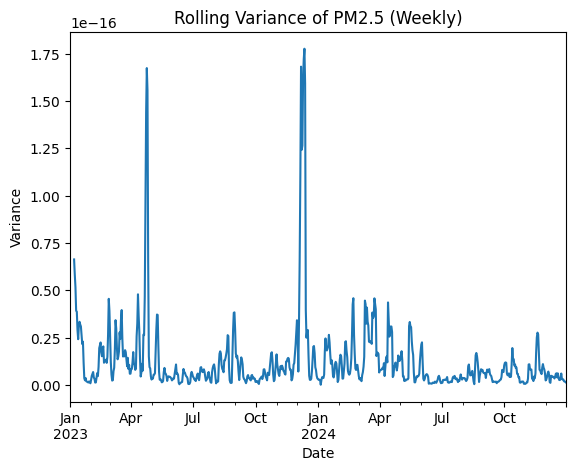


Stationarity tests:
Augmented Dickey-Fuller Test: ADF Test on PM2.5
Test Statistic                  -2.701130
p-value                          0.235614
#Lags Used                      13.000000
Number of Observations Used    717.000000
Critical Value (1%)             -3.971452
Critical Value (5%)             -3.416631
Critical Value (10%)            -3.130664
dtype: float64
Conclusion:====>
Failed to reject the null hypothesis and confirm that the time series is non-stationary


In [8]:

# Set 'timestamp' as the index for temporal analysis
if ddf.index.name != 'timestamp':
    ddf = ddf.set_index('timestamp')

# Hourly patterns (24-hour cycle)
print("\nHourly patterns (24-hour cycle):")
hourly_pm25 = ddf.groupby(ddf.index.hour)['pm25'].mean()
hourly_pm25.plot(title='Average PM2.5 by Hour of Day', xlabel='Hour', ylabel='PM2.5 (µg/m³)')
plt.show()

# Day of week effects (weekday vs weekend)
print("\nDay of week effects (weekday vs weekend):")
daily_pm25 = ddf.groupby(ddf.index.dayofweek)['pm25'].mean()
daily_pm25.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_pm25.plot(title='Average PM2.5 by Day of Week', xlabel='Day of Week', ylabel='PM2.5 (µg/m³)')
plt.show()

# Monthly trends and seasonal patterns
print("\nMonthly trends and seasonal patterns:")
monthly_pm25 = ddf.groupby(ddf.index.month)['pm25'].mean()
monthly_pm25.plot(kind='bar', title='Average PM2.5 by Month', xlabel='Month', ylabel='PM2.5 (µg/m³)')
plt.show()

# Year-over-year comparison (2023 vs 2024) with daily aggregation
print("\nYear-over-year comparison (daily means):")
years = ddf.index.year.unique()
if len(years) > 0:
    plt.figure(figsize=(12, 6))
    for year in years:
        try:
            yearly_data = ddf[ddf.index.year == year]['pm25'].resample('D').mean()
            yearly_data.plot(label=str(year))
        except KeyError as e:
            print(f"KeyError: {e}. Skipping year {year}.")
            continue
    plt.title('PM2.5 Daily Mean Time Series by Year')
    plt.xlabel('Date')
    plt.ylabel('PM2.5 (µg/m³)')
    plt.legend()
    plt.show()
else:
    print("No year data available for comparison.")

# Autocorrelation Analysis
print("\nAutocorrelation Analysis:")

# ACF and PACF plots
print("\nACF and PACF plots:")
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Aggregate to daily means for ACF/PACF if data is higher frequency
if ddf.index.inferred_freq is None or pd.infer_freq(ddf.index) not in ['D', 'W', 'M']:
    pm25_series = ddf['pm25'].resample('D').mean()
else:
    pm25_series = ddf['pm25']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(pm25_series.dropna(), lags=50, ax=axes[0], title='Autocorrelation Function (ACF)')
plot_pacf(pm25_series.dropna(), lags=50, ax=axes[1], title='Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()

# Lag correlation analysis: 1h, 3h, 6h, 12h, 24h, 1 week
print("\nLag correlation analysis: 1h, 3h, 6h, 12h, 24h, 1 week:")
lags = [1, 3, 6, 12, 24, 24*7]  # Lags in hours
lag_correlations = {}
for lag in lags:
    ddf[f'pm25_lag_{lag}h'] = ddf['pm25'].shift(lag)
    correlation = ddf['pm25'].corr(ddf[f'pm25_lag_{lag}h'])
    lag_correlations[lag] = correlation
    print(f"Correlation with lag {lag}h: {correlation:.2f}")

# Temporal Stability
print("\nTemporal Stability:")

# Variance over time, trend analysis
print("\nVariance over time, trend analysis:")
rolling_variance = pm25_series.rolling(window=7).var()  # Weekly rolling variance on daily data
rolling_variance.plot(title='Rolling Variance of PM2.5 (Weekly)', xlabel='Date', ylabel='Variance')
plt.show()

# Stationarity tests
print("\nStationarity tests:")
from statsmodels.tsa.stattools import adfuller

def adfuller_test(series, title=''):
    """Augmented Dickey-Fuller test for stationarity."""
    dftest = adfuller(series.dropna(), autolag='AIC', regression='ct')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(f'Augmented Dickey-Fuller Test: {title}')
    print(dfoutput)
    if dftest[1] <= 0.05:
        print("Conclusion:====>")
        print("Reject the null hypothesis and confirm that the time series is stationary")
    else:
        print("Conclusion:====>")
        print("Failed to reject the null hypothesis and confirm that the time series is non-stationary")

adfuller_test(pm25_series, title='ADF Test on PM2.5')

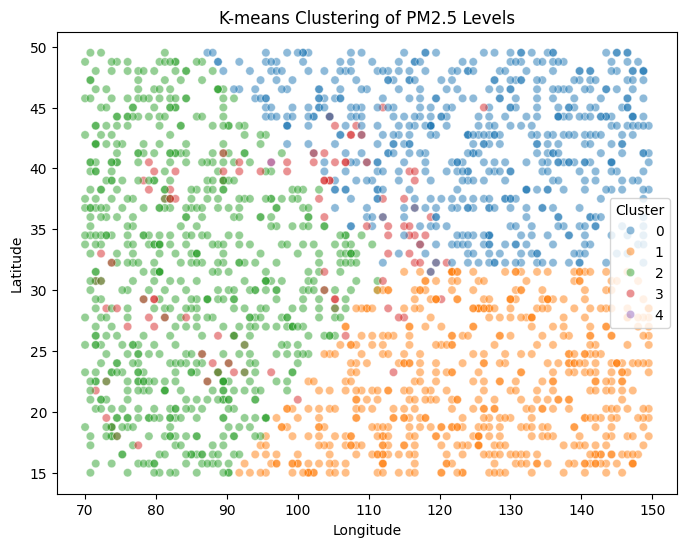

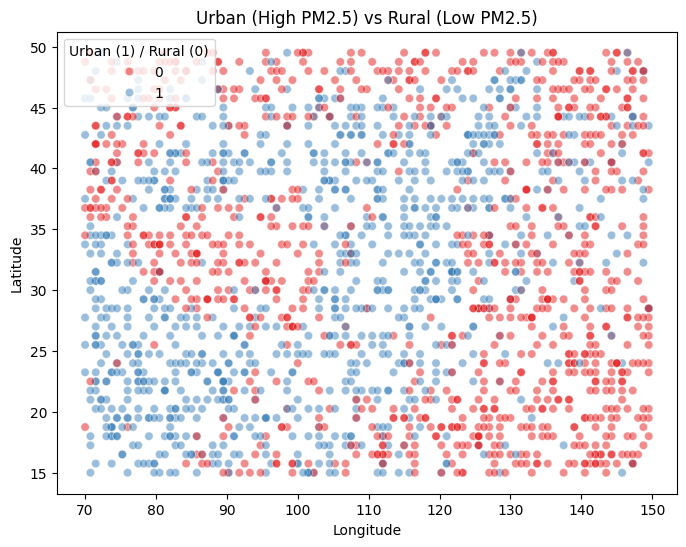

Moran's I: 0.273, p-value: 0.001


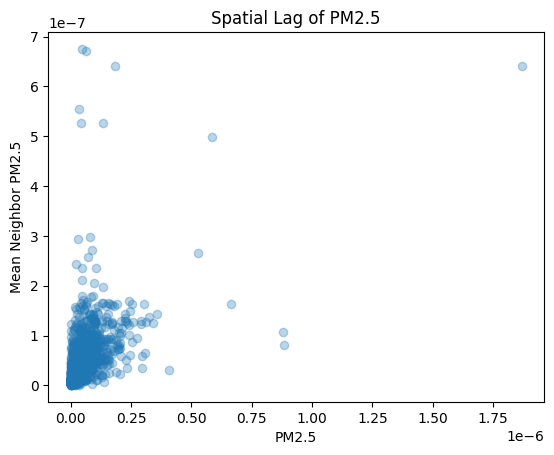

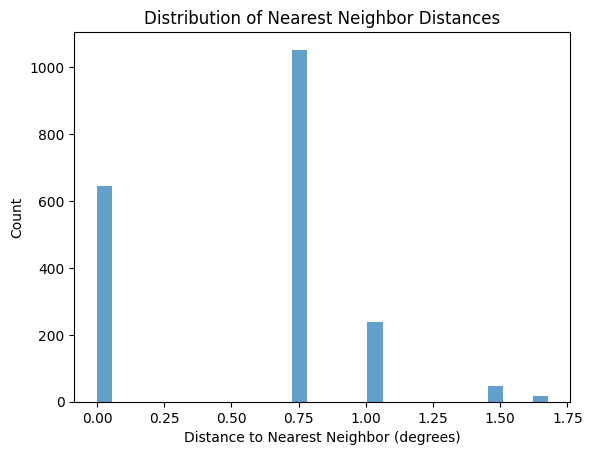

Top 10 regions by mean PM2.5:
region
40.5,96.2     1.025931e-06
37.5,82.8     8.773064e-07
39.8,94.8     5.860059e-07
40.5,105.2    5.277798e-07
40.5,106.8    5.028118e-07
42.8,107.5    4.131183e-07
27.8,79.0     3.421108e-07
26.2,88.8     2.957381e-07
37.5,115.0    2.957267e-07
35.2,115.0    2.922347e-07
Name: pm25, dtype: float32
Tokyo: Mean PM2.5 = 1.83e-08
Osaka: Mean PM2.5 = 1.91e-08
Beijing: Mean PM2.5 = 2.92e-07
Seoul: Mean PM2.5 = 9.74e-08
Potential industrial area PM2.5 hotspots:
                             lat     lon          pm25
timestamp                                             
2024-05-30 18:00:00+00:00  37.50   81.25  1.654546e-07
2024-01-17 18:00:00+00:00  18.75   73.75  2.097310e-07
2024-06-27 12:00:00+00:00  40.50   96.25  1.842091e-07
2023-02-18 18:00:00+00:00  34.50  118.00  2.342680e-07
2024-11-14 03:00:00+00:00  19.50   73.00  2.078259e-07


In [9]:
# --- Step 4: Spatial Patterns ---

# 1. Geographic Clustering: K-means clustering by pollution levels

sample_ddf = ddf.sample(2000, random_state=42)[['lat', 'lon', 'pm25']].dropna()
sample_ddf = sample_ddf.astype({'lat': np.float32, 'lon': np.float32, 'pm25': np.float32})
scaler = StandardScaler()
X = scaler.fit_transform(sample_ddf[['lat', 'lon', 'pm25']])
kmeans = KMeans(n_clusters=5, random_state=42)
sample_ddf['cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(8,6))
sns.scatterplot(data=sample_ddf, x='lon', y='lat', hue='cluster', palette='tab10', alpha=0.5)
plt.title('K-means Clustering of PM2.5 Levels')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Cluster')
plt.show()

# 2. Pollution hotspot identification (top 1% PM2.5) on actual map

hotspot = sample_ddf[sample_ddf['pm25'] > sample_ddf['pm25'].quantile(0.99)]

# Center map at mean location
center = [float(sample_ddf['lat'].mean()), float(sample_ddf['lon'].mean())]
m = folium.Map(location=center, zoom_start=6, tiles='cartodbpositron')

# Add all points as light grey
for row in sample_ddf.itertuples(index=False):
    folium.CircleMarker(
        location=[row.lat, row.lon],
        radius=2,
        color='lightgrey',
        fill=True,
        fill_opacity=0.2,
        opacity=0.2
    ).add_to(m)

# Add hotspots as red
for row in hotspot.itertuples(index=False):
    folium.CircleMarker(
        location=[row.lat, row.lon],
        radius=4,
        color='red',
        fill=True,
        fill_opacity=0.7,
        opacity=0.7
    ).add_to(m)

m

# 3. Rural vs urban classification (simple: lsm > 0.5 = land, <0.5 = sea; urban: pm25 > median)
sample_ddf['urban'] = (sample_ddf['pm25'] > sample_ddf['pm25'].median()).astype(np.uint8)
plt.figure(figsize=(8,6))
sns.scatterplot(data=sample_ddf, x='lon', y='lat', hue='urban', palette='Set1', alpha=0.5)
plt.title('Urban (High PM2.5) vs Rural (Low PM2.5)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Urban (1) / Rural (0)')
plt.show()

# 5. Spatial Autocorrelation: Moran's I statistic

coords = sample_ddf[['lat', 'lon']].values
w = libpysal.weights.KNN.from_array(coords, k=8)
moran = Moran(sample_ddf['pm25'], w)
print(f"Moran's I: {moran.I:.3f}, p-value: {moran.p_sim:.3f}")

# 7. Spatial lag features and distance decay analysis

tree = cKDTree(coords)
dists, idxs = tree.query(coords, k=5)
pm25_vals = sample_ddf['pm25'].values
spatial_lag = np.array([pm25_vals[idx[1:]].mean() for idx in idxs])
plt.scatter(pm25_vals, spatial_lag, alpha=0.3)
plt.xlabel('PM2.5')
plt.ylabel('Mean Neighbor PM2.5')
plt.title('Spatial Lag of PM2.5')
plt.show()

# 8. Distance Impact Analysis: PM2.5 accuracy vs distance to sensors (proxy: nearest neighbor)
plt.hist(dists[:,1], bins=30, alpha=0.7)
plt.xlabel('Distance to Nearest Neighbor (degrees)')
plt.ylabel('Count')
plt.title('Distribution of Nearest Neighbor Distances')
plt.show()

# 9. Regional Analysis: Prefecture-level aggregations (example: by rounding lat/lon)
sample_ddf['region'] = sample_ddf['lat'].round(1).astype(str) + ',' + sample_ddf['lon'].round(1).astype(str)
region_pm25 = sample_ddf.groupby('region')['pm25'].mean().sort_values(ascending=False)
print("Top 10 regions by mean PM2.5:")
print(region_pm25.head(10))

# 10. Major city analysis (Tokyo, Osaka, etc.)
cities = {
    'Tokyo': (35.6895, 139.6917),
    'Osaka': (34.6937, 135.5023),
    'Beijing': (39.9042, 116.4074),
    'Seoul': (37.5665, 126.9780)
}
for city, (clat, clon) in cities.items():
    mask = ((sample_ddf['lat']-clat).abs()<0.5) & ((sample_ddf['lon']-clon).abs()<0.5)
    city_pm25 = sample_ddf.loc[mask, 'pm25'].mean()
    print(f"{city}: Mean PM2.5 = {city_pm25:.2e}")

# 11. Industrial area identification (high PM2.5, not near major cities)
industrial = sample_ddf[sample_ddf['pm25'] > sample_ddf['pm25'].quantile(0.95)].copy()
for city, (clat, clon) in cities.items():
    dist = np.sqrt((industrial['lat']-clat)**2 + (industrial['lon']-clon)**2)
    industrial = industrial[dist > 1.0]
print("Potential industrial area PM2.5 hotspots:")
print(industrial[['lat', 'lon', 'pm25']].head())


The Moran's I of 0.262 and a p-value of 0.001 together indicate that there is a statistically significant, moderate positive spatial autocorrelation in your PM2.5 data. This suggests that PM2.5 levels tend to cluster spatially, with high values near other high values and low values near other low values. This is not unexpected, as pollution sources and weather patterns often affect neighboring locations similarly.

In [10]:
print("YELLOW DUST DATASET SUMMARY")
print("="*60)

print("\n📊 DATASET OVERVIEW:")
print(f"   Total records: {len(ddf):,}")
print(f"   Time period: {ddf.index.min().date()} to {ddf.index.max().date()}")
print(f"   Unique locations (lat, lon): {ddf[['lat', 'lon']].drop_duplicates().shape[0]}")

print("\n✅ DATA COMPLETENESS:")
completeness_pm25 = ddf['pm25'].notna().mean() * 100
print(f"   PM2.5: {completeness_pm25:.1f}%")

completeness_pm10 = ddf['pm10'].notna().mean() * 100
print(f"   PM10: {completeness_pm10:.1f}%")

completeness_t2m = ddf['t2m'].notna().mean() * 100
print(f"   Temperature (t2m): {completeness_t2m:.1f}%")

completeness_u10 = ddf['u10'].notna().mean() * 100
print(f"   Wind U (u10): {completeness_u10:.1f}%")

completeness_v10 = ddf['v10'].notna().mean() * 100
print(f"   Wind V (v10): {completeness_v10:.1f}%")

completeness_sp = ddf['sp'].notna().mean() * 100
print(f"   Surface Pressure (sp): {completeness_sp:.1f}%")

completeness_bcaod550 = ddf['bcaod550'].notna().mean() * 100
print(f"   Black Carbon AOD (bcaod550): {completeness_bcaod550:.1f}%")

completeness_duaod550 = ddf['duaod550'].notna().mean() * 100
print(f"   Dust AOD (duaod550): {completeness_duaod550:.1f}%")

completeness_lsm = ddf['lsm'].notna().mean() * 100
print(f"   Land-Sea Mask (lsm): {completeness_lsm:.1f}%")

print("\n🟢 KEY FINDINGS:")
print("   • Comprehensive data on PM2.5, PM10, weather variables, and aerosol optical depth")
print("   • Data available for spatial and temporal analysis of yellow dust events")
print("   • Multi-year trends available for analysis")

# --- Additional Code for Temporal Coverage ---
# Since 'timestamp' is the index, use .index instead of ['timestamp']
all_dates = pd.date_range(start=ddf.index.min(), end=ddf.index.max(), freq='D')

# Get the existing dates in the dataset
existing_dates = pd.to_datetime(ddf.index.date).unique()

print("\n📅 TEMPORAL COVERAGE:")
print(f"   Days with data: {len(existing_dates)}/{len(all_dates)} ({len(existing_dates)/len(all_dates)*100:.1f}%)")
print(f"   Data period: {(ddf.index.max() - ddf.index.min()).days} days")
if len(existing_dates) >= len(all_dates)-2:
    print("   ✓ COMPLETE COVERAGE FOR ANALYSIS PERIOD")

YELLOW DUST DATASET SUMMARY

📊 DATASET OVERVIEW:
   Total records: 29,409,592
   Time period: 2023-01-01 to 2024-12-31
   Unique locations (lat, lon): 5029

✅ DATA COMPLETENESS:
   PM2.5: 100.0%
   PM10: 100.0%
   Temperature (t2m): 100.0%
   Wind U (u10): 100.0%
   Wind V (v10): 100.0%
   Surface Pressure (sp): 100.0%
   Black Carbon AOD (bcaod550): 100.0%
   Dust AOD (duaod550): 100.0%
   Land-Sea Mask (lsm): 100.0%

🟢 KEY FINDINGS:
   • Comprehensive data on PM2.5, PM10, weather variables, and aerosol optical depth
   • Data available for spatial and temporal analysis of yellow dust events
   • Multi-year trends available for analysis

📅 TEMPORAL COVERAGE:
   Days with data: 731/731 (100.0%)
   Data period: 730 days
   ✓ COMPLETE COVERAGE FOR ANALYSIS PERIOD
